# Single-view (concatenation) based modelling

This modelling is distinct from the multi-view method. Mainly in that it concatenates the data before the analysis. Whereas multi-view simultaneously transforms each dataset into a common representation. I believe.

## Processing steps

These intial steps are mainly concerned with data wrangling.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pathlib import Path
from sklearn.metrics import classification_report
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold

import pandas as pd
import numpy as np
import pathintegrate
import sspa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import LeaveOneOut

In [2]:
project_root = Path.cwd().parent.parent.parent
print(project_root)

c:\Users\joddy\repos\plasticell_multiomics_integration


In [3]:
lcms_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'lcms.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'miRNA.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'olink.feather')
scRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'scRNA.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [4]:
# Extract vessel and day numbers
nk_cell_proportions[['vessel', 'day']] = nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
nk_cell_proportions['vessel'] = pd.to_numeric(nk_cell_proportions['vessel'])
nk_cell_proportions['day'] = pd.to_numeric(nk_cell_proportions['day'])
nk_cell_proportions['label'] = 'r4_v' + nk_cell_proportions['vessel'].astype(str) + '_d' + nk_cell_proportions['day'].astype(str)
subset_nk = nk_cell_proportions[nk_cell_proportions['label'].isin(combined_metadata['label'])]

In [5]:
conditions = [
    (subset_nk['day'] >= 1) & (subset_nk['day'] <= 3),
    (subset_nk['day'] >= 4) & (subset_nk['day'] <= 6),
    (subset_nk['day'] >= 8) & (subset_nk['day'] <= 12),
    (subset_nk['day'] >= 13) & (subset_nk['day'] <= 15),
    (subset_nk['day'] >= 19) & (subset_nk['day'] <= 26),
    (subset_nk['day'] >= 29) & (subset_nk['day'] <= 36)
]

# Define the corresponding values for each condition
values = [
    'mesoderm_commitment',
    'hemogenic_endothelium',
    'early_haem',
    'late_haem',
    'early_NK',
    'late_NK'
]

# Use np.select to assign values based on conditions
subset_nk['stage'] = np.select(conditions, values, default='undefined')

C:\Users\joddy\AppData\Local\Temp\ipykernel_9472\838363551.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [6]:
def gmt_to_wide_df(filepath):
    """
    Reads a GMT file and returns a DataFrame with each pathway as a row and each member in its own column.
    """
    rows = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway_id = parts[0]
            pathway_name = parts[1]
            members = parts[2:]
            row = [pathway_id, pathway_name] + members
            rows.append(row)
    # Find the maximum number of members
    max_members = max(len(row) for row in rows)
    # Pad rows so all have the same length
    for row in rows:
        row += [None] * (max_members - len(row))
    columns = ['Pathway_id', 'Pathway_name'] + [f'Member_{i+1}' for i in range(max_members-2)]
    return pd.DataFrame(rows, columns=columns)

# Usage:
local_gmt_path = project_root / "02_integration_tests" / "hierarchical_integration" / "Reactome_Homo_sapiens_pathways_multiomics_R92.gmt"
mo_paths = gmt_to_wide_df(local_gmt_path)

In [7]:
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

scRNA_data.index = scRNA_data['label']
scRNA_data = scRNA_data.drop(columns=['label'])

In [8]:
subset_nk = subset_nk.set_index('label').sort_index()

# Sort scRNA data and olink_data by their index in alphanumeric order
scRNA_data = scRNA_data.sort_index()
olink_data = olink_data.sort_index()

# Set subset_nk index to 'label' and sort in alphanumeric order
subset_nk = subset_nk.sort_index()

In [9]:
print(olink_data.index.equals(subset_nk.index))
print(scRNA_data.index.equals(subset_nk.index))

True
True


In [10]:
from sklearn.model_selection import train_test_split

# Use the proportion_NK as the stratification variable (binned for stratification)
stratify_bins = pd.qcut(subset_nk['proportion_NK'], q=4, duplicates='drop')

train_idx, test_idx = train_test_split(
    subset_nk.index,
    test_size=0.2,
    random_state=42,
    stratify=stratify_bins
)

olink_train = olink_data.loc[train_idx]
olink_test = olink_data.loc[test_idx]

scRNA_train = scRNA_data.loc[train_idx]
scRNA_test = scRNA_data.loc[test_idx]

subset_nk_train = subset_nk.loc[train_idx]
subset_nk_test = subset_nk.loc[test_idx]

In [11]:
print(scRNA_train.index.equals(subset_nk_train.index))

True


## Modelling

The model defined below uses the proportion of NK cells in a sample (from 0 to 1) as the target variable. Min_coverage is set to 2 as 4 was previously too stringent. 

In [12]:
# instantiate a model with the training data only
pi_model = pathintegrate.PathIntegrate(
    omics_data={'Proteomics_train': olink_train, 'scRNA_train': scRNA_train},
    metadata=subset_nk_train['proportion_NK'],
    pathway_source=mo_paths,
    sspa_scoring=sspa.sspa_SVD,
    min_coverage=2)

### Tuning the model

Only selected n_estimators to vary between 3 values (25, 50, 100).

In [ ]:
param_grid = {
    "model__max_features": [1, 8, 15], 
    "model__min_samples_leaf": [2, 11, 20], 
}

sv_grid_search = pi_model.SingleViewGridSearchCV(
    model=RandomForestRegressor,
    param_grid=param_grid,
    grid_search_params={'cv': 5,
                        'scoring':'neg_root_mean_squared_error',
                        'verbose':2, 
                        'n_jobs': -1}
)

Fitting 19 folds for each of 3 candidates, totalling 57 fits


In [28]:
sv_grid_search.best_params_

{'model__n_estimators': 50}

### Assessing the model

C:\Users\joddy\AppData\Local\Temp\ipykernel_27204\2584868831.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




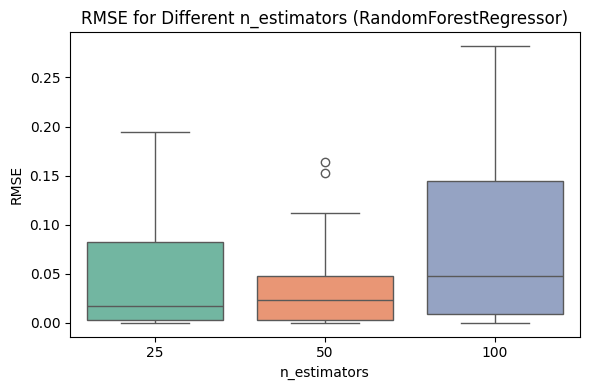

In [26]:
import seaborn as sns

# Extract n_estimators values
n_estimators = sv_grid_search.cv_results_['param_model__n_estimators'].data

# Collect all split keys
split_keys = [k for k in sv_grid_search.cv_results_.keys() if k.startswith('split') and k.endswith('_test_score')]

# Stack all split scores into a DataFrame
split_scores = np.vstack([sv_grid_search.cv_results_[k] for k in split_keys])  # shape: (n_splits, n_param_settings)

# Convert negative RMSE to positive RMSE
rmse_scores = -split_scores  # shape: (n_splits, n_param_settings)

# Prepare DataFrame for plotting (long-form)
rmse_df = pd.DataFrame({
    'n_estimators': np.repeat(n_estimators, rmse_scores.shape[0]),
    'RMSE': rmse_scores.flatten()
})

plt.figure(figsize=(6, 4))
sns.boxplot(x='n_estimators', y='RMSE', data=rmse_df, palette='Set2')
plt.title('RMSE for Different n_estimators (RandomForestRegressor)')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

## Final fit

In [27]:
sv_tuned = pi_model.SingleView(
    model=RandomForestRegressor,
    model_params={'n_estimators': 50, 'random_state':0}
    )

Generating pathway scores...


KeyboardInterrupt: 

In [17]:
# generate multi-omics pathway scores for test set
concat_data = pd.concat([olink_test, scRNA_test], axis=1)

pipe_sv = Pipeline([
            ('Scaler', StandardScaler().set_output(transform="pandas")),
            ('sspa', pi_model.sspa_method(pi_model.pathway_source, pi_model.min_coverage)),
        ])

test_set_scores = pipe_sv.fit_transform(concat_data)

# predict using the test set scores
sv_pred = sv_tuned.predict(test_set_scores)

from sklearn.metrics import mean_squared_error
import numpy as np

# evaluate the prediction using RMSE
test_set_rmse = np.sqrt(mean_squared_error(subset_nk_test['proportion_NK'], sv_pred))
print("Test set RMSE:", test_set_rmse)


Test set RMSE: 0.16479626997083985


In [18]:
# add R2 metrics
from sklearn.metrics import r2_score
test_set_r2 = r2_score(subset_nk_test['proportion_NK'], sv_pred)
print("Test set R2:", test_set_r2)

Test set R2: 0.757750814182761


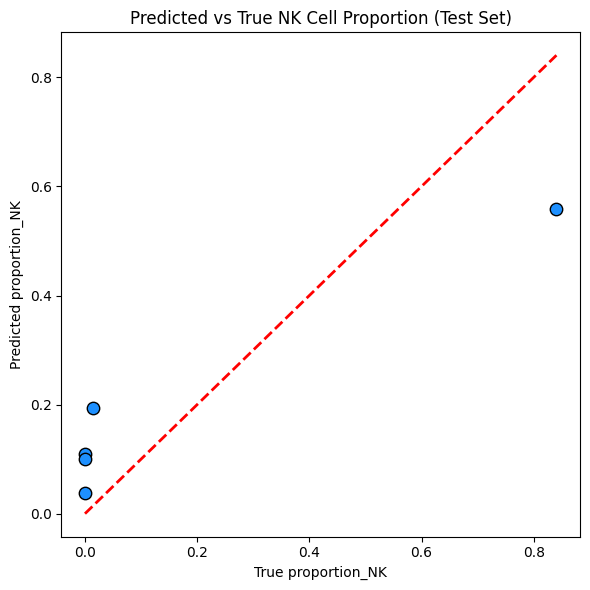

In [19]:
y_test_true = subset_nk_test['proportion_NK']

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, sv_pred, color='dodgerblue', edgecolor='k', s=80)
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--', lw=2)
plt.xlabel('True proportion_NK')
plt.ylabel('Predicted proportion_NK')
plt.title('Predicted vs True NK Cell Proportion (Test Set)')
plt.tight_layout()
plt.show()

## Features

In [ ]:
# Get feature importances from the trained RandomForestRegressor
sv_pathway_importance = pd.DataFrame(
    sv_tuned.feature_importances_,
    columns=['Importance'],
    index=sv_tuned.sspa_scores.columns
)

C:\Users\joddy\AppData\Local\Temp\ipykernel_16452\37155606.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




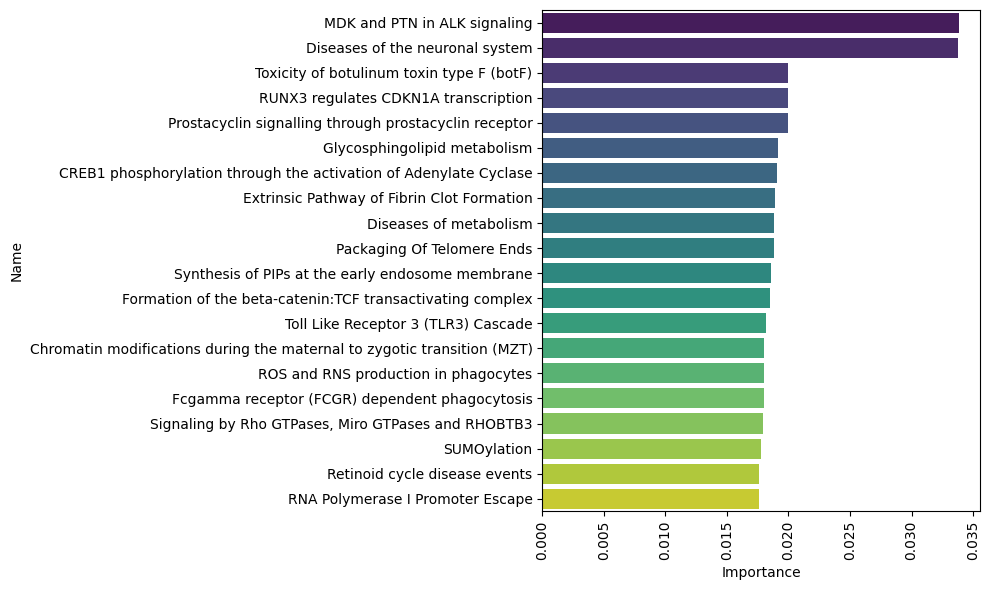

In [34]:
# Map pathway names by position (since your columns are integers)
sv_pathway_importance['Name'] = mo_paths['Pathway_name'].iloc[sv_pathway_importance.index].values

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sv_pathway_importance.sort_values(by='Importance', ascending=False).iloc[:20, :],
    x='Importance',
    y='Name',
    palette='viridis'
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Cross-validation

The above analysis only assesses the model using a single train/test split. So I will try to implement some cross-validation to make the model assessment more reliable.

The issue with this implementation though is that hyperparameter tuning (performed above) is performed on the same data for assessment, so is somewhat biased towards overfitting.

In [12]:
def ntile(series, n):
    # Assign ranks, then integer-divide into n bins
    return ((series.rank(method='first') - 1) // (len(series) / n)).astype(int)

# Example usage:
stratify_bins = ntile(subset_nk['proportion_NK'], 4).astype(str)

In [22]:
n_splits = 5
n_repeats = 10
random_state = 42
param_grid = {
    "model__max_features": [1, 8, 15], 
    "model__min_samples_leaf": [2, 11, 20], 
}

# Store results
all_rmse = []
all_r2 = []

model_counter = 0

for repeat in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state + repeat)
    for train_idx, test_idx in skf.split(subset_nk, stratify_bins):
        model_counter += 1
        print(f"Model #{model_counter}")
        train_idx = subset_nk.index[train_idx]
        test_idx = subset_nk.index[test_idx]
        
        olink_train = olink_data.loc[train_idx]
        olink_test = olink_data.loc[test_idx]
        scRNA_train = scRNA_data.loc[train_idx]
        scRNA_test = scRNA_data.loc[test_idx]
        y_train = subset_nk.loc[train_idx, 'proportion_NK']
        y_test = subset_nk.loc[test_idx, 'proportion_NK']
        
        # Fit PathIntegrate model
        pi_model = pathintegrate.PathIntegrate(
            omics_data={'Proteomics_train': olink_train, 'scRNA_train': scRNA_train},
            metadata=y_train,
            pathway_source=mo_paths,
            sspa_scoring=sspa.sspa_SVD,
            min_coverage=2
        )

        # Bin the training target for stratification
        stratify_bins_train = ntile(y_train, 4).astype(str)
        inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        # Perform grid search for hyperparameter tuning
        sv_grid_search = pi_model.SingleViewGridSearchCV(
            model=RandomForestRegressor,
            param_grid=param_grid,
            grid_search_params={
                'cv': inner_skf.split(y_train, stratify_bins_train),
                'scoring': 'neg_root_mean_squared_error',
                'verbose': 2,
                'n_jobs': -1
            }
        )

        # fit model with optimal hyperparameters
        sv_model = pi_model.SingleView(
            model=RandomForestRegressor,
            model_params={'max_features': sv_grid_search.best_params_['model__max_features'],
                          'min_samples_leaf': sv_grid_search.best_params_['model__min_samples_leaf'],
                          'n_jobs': -1
                          }
        )
        
        # Prepare test data
        concat_test = pd.concat([olink_test, scRNA_test], axis=1)
        pipe_sv = Pipeline([
            ('Scaler', StandardScaler().set_output(transform="pandas")),
            ('sspa', pi_model.sspa_method(pi_model.pathway_source, pi_model.min_coverage)),
        ])
        test_set_scores = pipe_sv.fit_transform(concat_test)
        sv_pred = sv_model.predict(test_set_scores)
        
        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_test, sv_pred))
        r2 = r2_score(y_test, sv_pred)
        all_rmse.append(rmse)
        all_r2.append(r2)

print(f"Mean RMSE: {np.mean(all_rmse):.3f} ± {np.std(all_rmse):.3f}")
print(f"Mean R2: {np.mean(all_r2):.3f} ± {np.std(all_r2):.3f}")

Model #1
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #2
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #3
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #4
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #5
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #6
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #7
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #8
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Generating pathway scores...
Fitting SingleView model
Model #9
Fitting

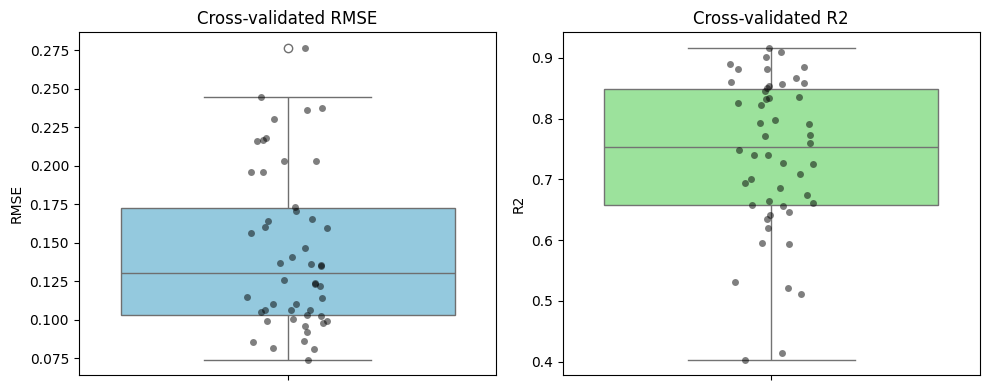

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
cv_results_df = pd.DataFrame({
    'RMSE': all_rmse,
    'R2': all_r2
})

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y='RMSE', data=cv_results_df, color='skyblue')
sns.stripplot(y='RMSE', data=cv_results_df, color='k', alpha=0.5, jitter=True)
plt.title('Cross-validated RMSE')
plt.ylabel('RMSE')

plt.subplot(1, 2, 2)
sns.boxplot(y='R2', data=cv_results_df, color='lightgreen')
sns.stripplot(y='R2', data=cv_results_df, color='k', alpha=0.5, jitter=True)
plt.title('Cross-validated R2')
plt.ylabel('R2')

plt.tight_layout()
plt.show()

In [24]:
# Save cross-validated RMSE and R2 results to feather file
pd.DataFrame({'RMSE': all_rmse, 'R2': all_r2}).reset_index(drop=True).to_feather(project_root / '00_data' / 'cross_validated_sv_metrics.feather')

## Getting feature importances from all data

Build model using all data, since we have already assessed model performance.

In [13]:
# instantiate a model with all the data
all_data_pi_model = pathintegrate.PathIntegrate(
    omics_data={'Proteomics_data': olink_data, 'scRNA_data': scRNA_data},
    metadata=subset_nk['proportion_NK'],
    pathway_source=mo_paths,
    sspa_scoring=sspa.sspa_SVD,
    min_coverage=2)

In [ ]:
all_data_param_grid = {
    "model__max_features": [1, 8, 15], 
    "model__min_samples_leaf": [2, 11, 20], 
}
# Create stratified splitter
all_data_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratify_bins = ntile(subset_nk['proportion_NK'], 4).astype(str)

all_data_sv_grid_search = all_data_pi_model.SingleViewGridSearchCV(
    model=RandomForestRegressor,
    param_grid=all_data_param_grid,
    grid_search_params={
        'cv': all_data_skf.split(subset_nk, stratify_bins),
        'scoring': 'neg_root_mean_squared_error',
        'verbose': 2,
        'n_jobs': -1
    }
)

TypeError: GridSearchCV.__init__() got an unexpected keyword argument 'random_state'

In [17]:
# fit model with optimal hyperparameters
all_data_sv_model = all_data_pi_model.SingleView(
    model=RandomForestRegressor,
    model_params={'max_features': all_data_sv_grid_search.best_params_['model__max_features'],
                    'min_samples_leaf': all_data_sv_grid_search.best_params_['model__min_samples_leaf'],
                    'n_jobs': -1
                    }
)

Generating pathway scores...
Fitting SingleView model


In [18]:
# Get feature importances from the trained RandomForestRegressor
all_data_sv_pathway_importance = pd.DataFrame(
    all_data_sv_model.feature_importances_,
    columns=['Importance'],
    index=all_data_sv_model.sspa_scores.columns
)

C:\Users\joddy\AppData\Local\Temp\ipykernel_9472\485295905.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




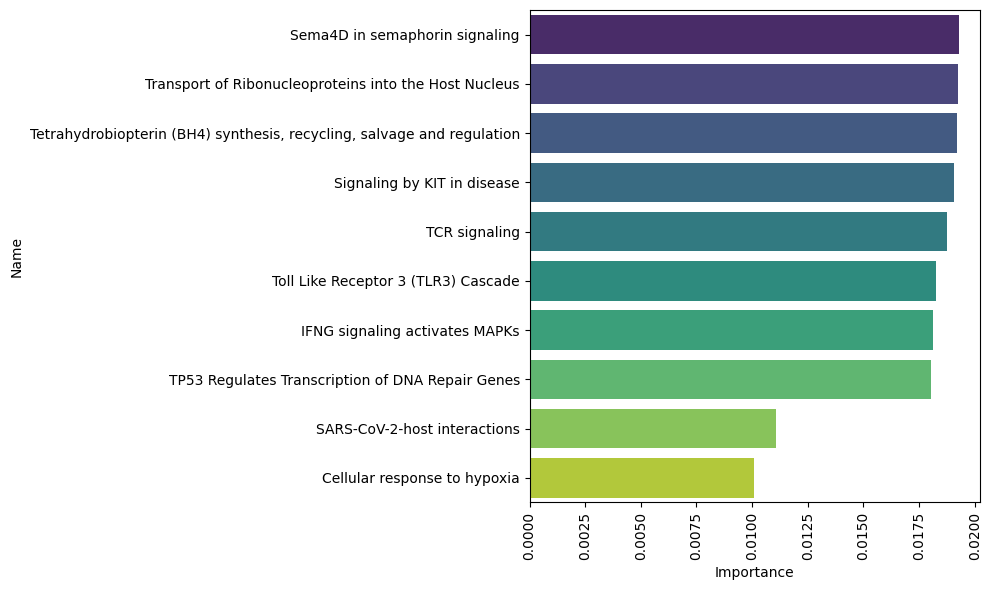

In [25]:
# Map pathway names by position (since your columns are integers)
all_data_sv_pathway_importance['Name'] = mo_paths['Pathway_name'].iloc[all_data_sv_pathway_importance.index].values

plt.figure(figsize=(10, 6))
sns.barplot(
    data=all_data_sv_pathway_importance.sort_values(by='Importance', ascending=False).iloc[:10, :],
    x='Importance',
    y='Name',
    palette='viridis'
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# save pathway importance to feather file
all_data_sv_pathway_importance.reset_index().to_feather(project_root / '00_data' / 'feature_importances' / 'hierarchical_integration_feature_importances.feather')